# LP Sales Pitch: AMMs as Continuum of Put Options

**LP:** 

- I am selling "merchant" price insurance for selling $R_X$ regardles of $P_T$.
- I am buying $R_X$ at $\psi_{\text{bid}}$. Then if $P_T < \psi_{\text{bid}}$ you a sure buyer at $\psi_{\text{bid}}$ earning a realized premia of $\psi_{\text{bid}} - P_T > 0 $.

- If $P_T > \psi_{\text{bid}}$ do not worry you sell your $\Delta X \leq R_X$ at $P_T$, and this never gets executed
$$
\begin{cases}
    \mathsf{buyer} := \left(\psi_{\text{bid}} - P_T\right)^+ - \mathsf{premia} \\
    \mathsf{seller} := \mathsf{premia} - \left(\psi_{\text{bid}} - P_T\right)^+
\end{cases}
$$




**LP "Thought process incentive":**

Mmm... I want to buy $R_X$ at $\psi_{\text{bid}}$ or lower. If the market ($P_0 = \psi (P)$) never offers me that price, fine - pay me for waiting

If the market does offer it, great - I buy at the price I wanted anyway $\psi_{\text{bid}}$.

Now, I am willing to give up the right to buy at $P_T < \psi_{\text{bid}}$, in exchange for being paid now to guarantee that I will buy at $\psi_{\text{bid}}$ if the market offers it.








**Trader**: I'm in, I can't afford selling $\Delta X \leq R_X$ at $P_T$, ($\psi_{\text{bid}}$ is definetely a stop-loss for me) How much is this insurance you sell?


**LP** Well, current market price is $P_0$. Let me think ...

*I need to determine my expected worst-case scenario.*

*What is the expected cost of me making this promise?*

*If $\psi_{\text{bid}} < P_T < P_0$, then I am not purchasing $R_X$ and the trader remains at his order threshold; so, nothing happens (the cost is zero). On the other hand, if $P_T < \psi_{\text{bid}}$, then my opportunity cost becomes $\psi_{\text{bid}} - P_T$.*

*I see more clearly: now $P$ is non-deterministic, and if I consider an abstract measure of my future expectation of $P$, then...*



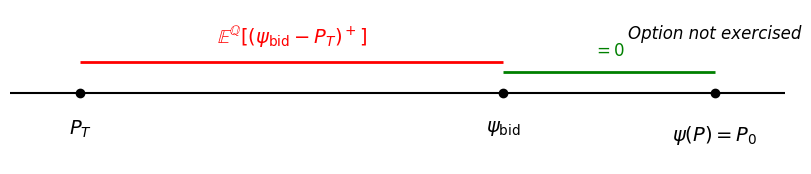

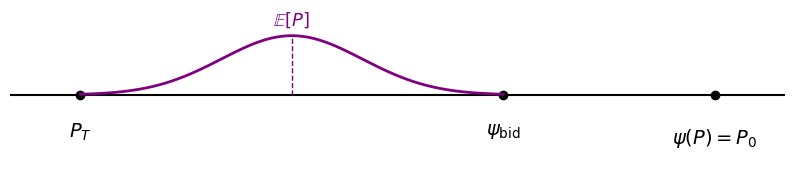

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2))

# Define x positions for the points
x_PT = 0
x_expectation = 3
x_psib = 6
x_zero = 9

# Draw x-axis
ax.hlines(y=0, xmin=x_PT-1, xmax=x_zero+1, color='black')

# Mark the points only for PT, psib, and zero (not for expectation and zero since those will be marked as segments)
ax.plot([x_PT], [0], 'ko')
ax.plot([x_psib], [0], 'ko')
ax.plot([x_zero], [0], 'ko')

# Annotate the points WITHOUT \text
ax.text(x_PT, -0.11, r'$P_T$', ha='center', va='top', fontsize=14, fontweight='bold')
ax.text(x_psib, -0.11, r'$\psi_{\mathrm{bid}}$', ha='center', va='top', fontsize=14, fontweight='bold')
ax.text(x_zero, -0.13, r'$\psi(P) = P_0$', ha='center', va='top', fontsize=14, fontweight='bold')

# Use a distance segment for the expectation
ax.hlines(y=0.13, xmin=x_PT, xmax=x_psib, color='red', linewidth=2)
ax.text((x_PT+x_psib)/2, 0.18, r'$\mathbb{E}^{\mathbb{Q}}\left[(\psi_{\mathrm{bid}} - P_T)^+\right]$', ha='center', va='bottom', fontsize=14, color='red')

# Use a distance segment for distance = 0 (between psib and 0)
ax.hlines(y=0.09, xmin=x_psib, xmax=x_zero, color='green', linewidth=2)
ax.text((x_psib+x_zero)/2, 0.14, r'$=0$', ha='center', va='bottom', fontsize=12, color='green')

# Option not exercised at x_zero (no \textit)
ax.text(x_zero, 0.21, 'Option not exercised', ha='center', va='bottom', fontsize=12, style='italic')

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(x_PT-1, x_zero+1)
ax.set_ylim(-0.3, 0.35)
plt.box(False)
plt.show()

# Plot the same x-axis with labels, but between Pt and psi_bid draw a minimal normal density, and mark/label the mean as E()
import numpy as np
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(10, 2))

# Define x positions for the points
x_PT = 0
x_psib = 6
x_zero = 9

# Draw x-axis
ax.hlines(y=0, xmin=x_PT-1, xmax=x_zero+1, color='black')

# Mark PT, psi_bid, and zero
ax.plot([x_PT], [0], 'ko')
ax.plot([x_psib], [0], 'ko')
ax.plot([x_zero], [0], 'ko')

# Annotate the points
ax.text(x_PT, -0.11, r'$P_T$', ha='center', va='top', fontsize=14, fontweight='bold')
ax.text(x_psib, -0.11, r'$\psi_{\mathrm{bid}}$', ha='center', va='top', fontsize=14, fontweight='bold')
ax.text(x_zero, -0.13, r'$\psi(P) = P_0$', ha='center', va='top', fontsize=14, fontweight='bold')

# Draw minimal normal density between Pt and psi_bid
x_density = np.linspace(x_PT, x_psib, 200)
mu = (x_PT + x_psib)/2
sigma = (x_psib - x_PT)/6  # narrow enough so bell is visible but in subinterval
y_density = norm.pdf(x_density, loc=mu, scale=sigma)
# scale vertically to fit nicely
y_density_scaled = 0.25 * y_density / y_density.max()

ax.plot(x_density, y_density_scaled, color='purple', lw=2)

# Draw vertical line at mean and label it E()
ax.vlines(mu, 0, norm.pdf(mu, loc=mu, scale=sigma)*0.25/y_density.max(), color='purple', linestyle='--', linewidth=1)
ax.text(mu, max(y_density_scaled)+0.03, r'$\mathbb{E}[P]$', ha='center', va='bottom', fontsize=13, color='purple', fontweight='bold')

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(x_PT-1, x_zero+1)
ax.set_ylim(-0.3, 0.35)
plt.box(False)
plt.show()

Ok this means that all the opprotunity costs for inifinitesimal price changes over the price distrubution on $[P_T, \psi_{\text{bid}}]$ is my expected opprotunity cost for selling this promise. I see ...
$$
\int_{P_T}^{\psi_{\text{bid}}} \big (\psi_{\text{bid}} - P \big)\cdot f_{P_T} (P) dP
$$


*Mmm... However, I am not setting an expiration or maturity for this promise. So what drives prices economically is supply and demand dynamics realized through trading volume flow. If I consider a trading volume path:*
 $$
 \hat{\Delta}: [0, \Delta] \to \mathbb{R} \implies P \big (\hat{\Delta}\big)
 $$
 
*I am pricing this in cash \$, then:*
 
 $$
 P_{\$/(P_0, \psi_{\text{bid}})} = \mathbb{E}^{\hat{\Delta}} \bigg [ \int_{\hat{\Delta}} \big (\psi_{bid} - P (\Delta)\big)^+\cdot \big (-d\Delta\big)\bigg]
 $$
 
*Hey... this is it, the fair price of the put is the expected total loss I incur by absorbing sell flow along all possible order flow paths that push the price below my bid* $\psi_{\text{bid}}$.


**LP:** Yes, the price is 
$$
 P_{\$/(P_0, \psi_{\text{bid}})} = \mathbb{E}^{\hat{\Delta}} \bigg [ \int_{\hat{\Delta}} \big (\psi_{bid} - P (\Delta)\big)^+\cdot \big (-d\Delta\big)\bigg]
$$
 

This is the price I am selling the promise of buying $R_X$ at $\psi_{\text{bid}}$. Do we close the deal ?

**Trader:** Hold on; Let me price this myself to determine wheter or not this is fair.

*If sell preassure triggers my stop-loss $P(\hat{\Delta}) < \psi_{\text{bid}}$ How much value do I loss relative to being able to exit at $\psi_{\text{bid}}$ ?*

$$
\int_{\hat{\Delta}} \big (\psi_{\text{bid}} - P(\Delta) \big )^+ (-d\Delta)
$$

*I see, so on average this insurance saves me ...*
$$
\mathbb{E}^{\hat{\Delta}} \bigg [\int_{\hat{\Delta}} \big (\psi_{\text{bid}} - P(\Delta) \big )^+ (-d\Delta) \bigg ]
$$


**Trader:** Yes, that is fair pricing. Let's close the deal ...

**LP:** This guy just accepted my promise; we need a platform to clear and settle our order...

 **Trader:** This all sounds great, but I do not trust this guy will fulfill his promise... Let's look for a SaaS (**Option Clearing House**) that helps us settle the trade.


**AMM SDR:** Guys, I got you covered. Here is the deal:
- LP, tell me the **strike** $\psi_{\text{bid}}$ and the collateral $R_Y$ that settles $\Delta X \leq R_X$.
- Trader, deposit the underlying $\Delta X \leq R_X$.

... Here is how it works...


**AMM SDR:** For the LP

→ I will require you to buy $\Delta X$ progressively using the collateral $R_Y$ as the $-d\Delta$ sell flow pushes $P_0 \to \psi_{\text{bid}}$.

→ Every trader that uses your collateral $R_Y$ to settle trades $\Delta_i < \Delta X$ pays $\phi(\Delta_i)$.

Once $\sum \Delta_i = \Delta X,$ you will receive the premium you asked for:

$$
P_{\$/(P_0, \psi_{\text{bid}})} = \phi (\Delta X)
$$

Now, if the price never reaches your bid, $P\big(\sum \Delta_i\big) > \psi_{\text{bid}}$, and you do not withdraw your collateral, you still earn fees and ends with zero net $\Delta X$.


> These fees are not the full premium, but the premium for the absorbed volume your collateral supported up to $P\big(\sum \Delta_i\big)$. 

On the other hand, If $P (\sum \Delta_i) \leq \psi_{\text{bid}}$ you buy $\Delta$ at $\psi_{\text{bid}}$ and $\phi (\sum \Delta_i) = P\big(\sum \Delta_i\big)$ is collected and deposited to you. 

... Any questions so far ?


**LP:** Okay, let me think of some questions ...

*He says the buying of $\Delta X$ is not atomic, but progressive until the price reaches $\psi_{\text{bid}}$.*

*At first glance, that kind of progress introduces a lot of risks ...*

*The other thing he mentioned is that trading volume $\hat{\Delta}$ uses my collateral $R_Y$. This means*


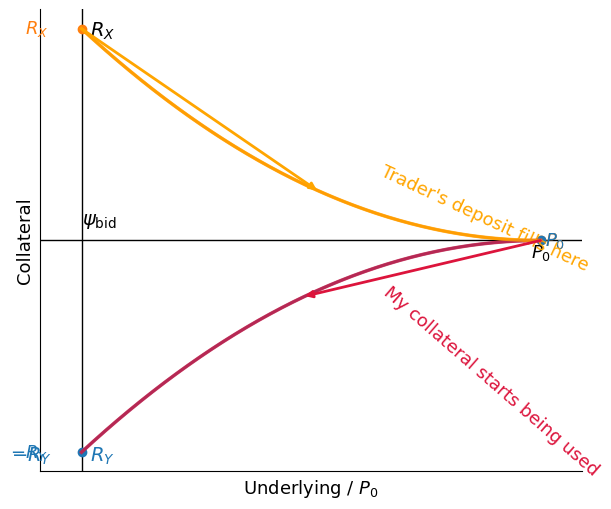

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))

# Axes ranges to cover quadrants I and IV
x = np.linspace(0, 1.2, 400)
y = np.linspace(-1.2, 1.2, 400)

# Draw axes
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Set x and y limits to cover quadrants I and IV
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-1.2, 1.2)

# Label axes with LaTeX
ax.set_xlabel(r'Underlying / $P_0$', fontsize=13)
ax.set_ylabel(r'Collateral', fontsize=13)

# Annotate origin as \psi_{bid}
ax.text(0, 0.05, r'$\psi_{\text{bid}}$', fontsize=14, ha='left', va='bottom')

# Positive y axis: R_X
ax.text(0.02, 1.09, r'$R_X$', fontsize=14, ha='left', va='center')

# Negative y axis: R_Y
ax.text(-0.07, -1.12, r'$-R_Y$', fontsize=14, ha='right', va='center', color='C0')
ax.text(0.02, -1.12, r'$R_Y$', fontsize=14, ha='left', va='center', color='C0')

# Draw correct convex curve in Q1: from (0, R_X) decreasing convexly to (P_0, 0)
_rx = 1.1  # maximum x (P_0)
_Rx = 1.1  # maximum collateral for R_X

curve_x1 = np.linspace(0, _rx, 300)
curve_y1 = _Rx * (1 - (curve_x1 / _rx))**2  # y = R_X at x=0, y = 0 at x=_rx, convex downwards

# Plot the first curve
ax.plot(curve_x1, curve_y1, color='C1', linewidth=2)
ax.plot([0], [_Rx], 'o', color='C1')  # Mark (0, R_X)
ax.plot([_rx], [0], 'o', color='C1')  # Mark (P_0, 0)
ax.text(-0.08, _Rx, r'$R_X$', fontsize=13, ha='right', va='center', color='C1')
ax.text(_rx+0.01, 0, r'$P_0$', fontsize=13, verticalalignment='center', color='C1')

# Mark P_0 on x-axis
ax.text(_rx, -0.09, r'$P_0$', fontsize=13, ha='center')

# Curve is in the 4th quadrant: starts at (0, -R_Y) and goes to (P_0, 0) while staying below y=0 (negative y)
_ry = 1.1  # R_Y value (magnitude, positive)
curve_x2 = np.linspace(0, _rx, 300)
curve_y2 = -_ry * (1 - (curve_x2 / _rx))**2

ax.plot(curve_x2, curve_y2, color='C0', linewidth=2)
ax.plot([0], [-_ry], 'o', color='C0')   # Mark (0, -R_Y)
ax.plot([_rx], [0], 'o', color='C0')    # Mark (P_0, 0)
ax.text(-0.08, -_ry, r'$-R_Y$', fontsize=13, ha='right', va='center', color='C0')
ax.text(_rx+0.01, 0, r'$P_0$', fontsize=13, verticalalignment='center', color='C0')

# HIGHLIGHT curve in Q4 (negative collateral): from (P_0, 0) to (0, -R_Y)
n_arrow_curve2 = 40
curve_arrow_x2 = np.linspace(_rx, 0, n_arrow_curve2)
curve_arrow_y2 = -_ry * (1 - (curve_arrow_x2 / _rx))**2
ax.plot(curve_arrow_x2, curve_arrow_y2, color='crimson', linewidth=2.5, zorder=4, alpha=0.8)

# ARROW Q4: tail at (P_0, 0), head at about halfway along the curve toward (0, -R_Y)
arrow_tail_x2 = _rx
arrow_tail_y2 = 0

arrow_head_fraction2 = 0.5  # 50% of the way from (P_0, 0) to (0, -R_Y)
arrow_head_idx2 = int(n_arrow_curve2 * arrow_head_fraction2)
arrow_head_x2 = curve_arrow_x2[arrow_head_idx2]
arrow_head_y2 = curve_arrow_y2[arrow_head_idx2]

ax.annotate(
    '',
    xy=(arrow_head_x2, arrow_head_y2),          # Arrow head: middle of Q4 convex curve
    xytext=(arrow_tail_x2, arrow_tail_y2),      # Arrow tail: (P_0, 0)
    arrowprops=dict(facecolor='crimson', edgecolor='crimson', arrowstyle='-|>', lw=2, shrinkA=0, shrinkB=0),
    zorder=5
)

# Label above the Q4 curve arrow -- "My collateral starts being used"
lbl_idx2 = int(n_arrow_curve2 * 0.36)
ax.text(
    curve_arrow_x2[lbl_idx2] + 0.01,
    curve_arrow_y2[lbl_idx2] - 0.08,
    r'My collateral starts being used',
    fontsize=13,
    color='crimson',
    rotation=-41,
    va='top'
)

# HIGHLIGHT curve in Q1 (positive collateral): from (0, R_X) to (P_0, 0)
n_arrow_curve1 = 40
curve_arrow_x1 = np.linspace(0, _rx, n_arrow_curve1)
curve_arrow_y1 = _Rx * (1 - (curve_arrow_x1 / _rx))**2
ax.plot(curve_arrow_x1, curve_arrow_y1, color='orange', linewidth=2.5, zorder=4, alpha=0.8)

# ARROW Q1: tail at (0, R_X), head at about halfway along the curve toward (P_0, 0)
arrow_tail_x1 = 0
arrow_tail_y1 = _Rx

arrow_head_fraction1 = 0.5  # 50% of the way from (0, R_X) to (P_0, 0)
arrow_head_idx1 = int(n_arrow_curve1 * arrow_head_fraction1)
arrow_head_x1 = curve_arrow_x1[arrow_head_idx1]
arrow_head_y1 = curve_arrow_y1[arrow_head_idx1]

ax.annotate(
    '',
    xy=(arrow_head_x1, arrow_head_y1),          # Arrow head: middle of Q1 convex curve
    xytext=(arrow_tail_x1, arrow_tail_y1),      # Arrow tail: (0, R_X)
    arrowprops=dict(facecolor='orange', edgecolor='orange', arrowstyle='-|>', lw=2, shrinkA=0, shrinkB=0),
    zorder=5
)

# Label above the Q1 curve arrow
lbl_idx1 = int(n_arrow_curve1 * 0.70)
ax.text(
    curve_arrow_x1[lbl_idx1] - 0.08,
    curve_arrow_y1[lbl_idx1] + 0.03,
    r"Trader's deposit fills here",
    fontsize=13,
    color='orange',
    rotation=-25,
    va='center'
)

# Remove right & top spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

  **LP:** Ok, so buying progressively implies that my execution price and my premium are the aggregate premium and execution price of the trades that moved the price to my strike....
 
 
  Let me focus first on the execution price... How do you guarantee all trades $\Delta X_i$ on any path consume the collateral $r_y$ such that the remaining collateral guarantees I can fund the trades that achieve buying $\Delta X$ at my bid $\psi_{\text{bid}}$ if the path follows my direction?

**AMM SDR:** I see where you're coming from. You are asking: if for any $\Delta_i < \Delta$ that uses $r_y < R_Y$, how do we guarantee $\Delta X - \Delta_i$ is supported by $R_Y - r_y$?

*Hmm, the LP is asking what guarantees the solvency of his collateral at all trades. Most notably, he wants to buy at $\psi_{\text{bid}}$, making sure his realized bid is not affected by the path taken to get there. Well, this is path-independence. The LP wants to know if we offer that determinism in the pricing rule over the trading volume path.*

That is a valid concern. Let me put it in simpler economic terms, setting aside jargon from now on.

 The underlying logical construction of the economic argument is 

*"After some early trade $\Delta X < R_X$ that consumes a portion of the LP's collateral $r_y < R_Y$, how do we guarantee the remaining collateral $R_Y - r_y$ can still buy $R_X - \Delta X$ at $\psi_{\text{bid}}$?"*

Great, formally this tarnslates to:

$$
\forall_{\Delta X \in \hat{\Delta }} \, \, \big ( R_Y - r_y \big) \geq \psi_{\text{bid}} \big (R_X - \Delta X\big)
$$

Ok, let me solve for this. I need to get to $X$ territory. Well we define a internal pricing rule as:

$$
r_y = \int_{0}^{\Delta X} P(\Delta)d\Delta \\
\implies \\
\\
\forall{\Delta \in \hat{\Delta}} \,  \, \underbrace{\int_{0}^{\Delta} P(u)\cdot du}_{\text{average trade execution price}} \underbrace{\geq}_{\text{is never worse than }} \underbrace{\psi_{\text{bid}}\cdot \Delta}_{\text{the trade priced at the bid}}
$$

Additionaly the whole collateral $R_Y$ is the pruchasing power of $R_X$ at $\psi_{\text{bid}}$, formally, it is a boundary condition $R_Y = \psi_{\text{bid}}\cdot R_X$, then we have:

$$
R_Y - \int_{0}^{\Delta} P(u)\, du \geq \psi_{\text{bid}} \cdot (R_X - \Delta) \\
\implies \\
\psi_{\text{bid}} \cdot R_X - \int_{0}^{\Delta} P(u)\, du \geq \psi_{\text{bid}} \cdot R_X  - \psi_{\text{bid}} \Delta \\
\implies \\

\int_{0}^{\Delta} P(u)\, du \geq \psi_{\text{bid}} \cdot \Delta\\
$$
This shows him that every trade using his collateral towards trading volume in the direction of his bid over-guarantees execution at $\psi_{\text{bid}}$ (traders buy at a higher price than him).

Perfect, that works for the solvency argument of his collateral.

Now let's go from this *global* condition to something more local to solve for path-independence. Essentially, the LP also asks:

*"Can an early infinitesimal trade consume too much collateral and break his ability to fund the remaining trades at some point, thus breaking solvency?"*




Well for this ...:

$$
\frac{\partial}{\partial \Delta} \left( \int_{0}^{\Delta} P(u)\, du \right) \geq  \frac{\partial}{\partial \Delta} \left( \psi_{\text{bid}} \cdot \Delta \right) \\
\implies \\
P(\Delta) \geq \psi_{\text{bid}} \qquad \text{for } \Delta \leq R_X
$$




**LP:** You said it well, I was looking for the guarantees of $R_Y = \psi_{\text{bid}}\cdot R_X$. My bid is of type price, $\psi_{\text{bid}} = \underbrace{\frac{R_Y}{R_X}}_{\text{how my collateral fits my purchase}}$.

This pricing rule you defined in the last inequality, $P(\Delta)$, seems to map trades to prices because it is comparable with $\psi_{\text{bid}}$, however it is still a black-box to me. How do you make sure it is of price type, and what properties does this pricing rule have to mee
t your solvency and path-independence claim?


**AMM SDR:** Right, notice that by construction
$$
\underbrace{r_y}_{\text{collateral spent to acquire} \, \Delta \text{units}} = \int_{0}^{\Delta X} P(\Delta)d\Delta
$$


By relying on dimensional analysis, the left-hand side integrates over $X$ volume and the right-hand side over units of collateral $Y$. Therefore, $P$ has units $Y/X$, as you correctly outlined for $\psi_{\text{bid}}$.

Now notice that for every infinitesimal expenditure of collateral $-dR_Y$ to acquire the corresponding proportional amount of underlying $dR_X$, this defines the marginal price:

$$
-dR_Y = P\cdot dR_X
$$

Well, notice that given initial conditions for the reserves $(R_X^0, R_Y^0)=(0,R_Y)$, solving the **ODE**:

$$
\frac{-dR_Y}{dR_X} = P(R_X, R_Y)
$$

produces a **curve** in the $(R_X, R_Y)$ space, which is the set of all reserve statres reachable from the initial state.


Now, to derive path-independence, the multivariable calculus theorem says that for any path on the reserve space $\hat{\Delta}$, the line integral

$$
\texttt{path-independent} \left( \int_{\hat{\Delta}} P\, dR_X,\, \hat{\Delta} \right) \iff P = \nabla \varphi,\ \varphi : (R_X, R_Y) \to \mathbb{R}
$$

$$
P: \hat{\Delta} \to \mathbb{R}_+ \\
\implies \\
R = (R_X, R_Y) \in \hat{\Delta} \, P(R_X, R_Y) \\
\implies \\
P \big (R_X, R_Y \big) = \psi_{\text{bid}}
$$
Your bid enters a a boundary condition.

- Selling preassure reduces price, also narrows the sapce of our internal pricing rule

$$
\nabla_X P \leq 0
$$

The fact that you buy along the path at increasingly better prices is a convexity constraint.


**LP:** Ok, got it.
 
- I am convinced that this pricing rule won't ever make me buy above my bid.

- And my collateral is safe at every step (I am always solvent).

Now, your mechanism for paying me the premium $P_{\$/(\psi_{\text{bid}},P_0)}$ is 
through a transaction fee $\phi$ on every trade executed within $[\psi_{\text{bid}}, P_0]$.

However, I see a problem: my premium depends on traders being incentivized to sell me $\Delta X$ at $P \in [\psi_{\text{bid}}, P_0]$. But I am aware there are other markets where you can sell $X$. So, I think you see my point.


Traders won't sell me $\Delta X$ if the external price is above your price plus the transaction fee charged for the trade. Thus, this entire mechanism is useless if no one is selling to me.

**AMM SDR:** You are right, and indeed the participation constrain is that:

$$
\forall_{\Delta \in \hat{\Delta}} P(\Delta) - \phi (\Delta) \geq P_{\text{EXT}} (
    \Delta
)
$$

Then, your question is  more, How do we make sure our pricing rule is at competitive as external price for all orders ?.

And indeed:

$$
P_{\text{EXT}} (\Delta) + \phi (\Delta) \leq P(\Delta) \leq \psi_{\text{bid}} \\

$$

...

$$
\partial_{\Delta} P \geq \partial_{\Delta} P_{\text{EXT}} + \partial_{\Delta} \phi
\
$$

Ok, now I need to touch on some delicate details, we have stale prices. We rely on arbs to rebalance the path so it matches the external price, they tarde the misspracing and they do so if and only if:

$$
\Pi^{\text{\texttt{arb}}} \big (\Delta \big)= \big | P_{\text{EXT}} \big (\Delta )- \big( P (\Delta ) + \phi(\Delta) \big)\big | > 0 \\
\implies \\
\\
\delta (P, P_{\text{EXT}}) \geq \phi (\Delta) 
$$

So, our control variable is 

$$
\phi:\Delta \to [0,1]
$$

globally bounded above by the missipricing



**LP** 


Yes, that is obvious, but still $P_{\text{EXT}}$ needs to be tracked over $\Delta$, or at least an estimate is required to calculate the optimal fee for upcoming arbitrages correcting the market. 

... Do you do that? 

Now, $P_{\text{EXT}}$ is exogenous, so $\phi$ indirectly depends on it, and thus my assumption is that:
- it cannot be fully deterministic.
- it is not path-dependent.


Remember, we are talking about my premium here !!

So how do you make sure I get paid my premium $P_{\$/(\psi_{\text{bid}}, P_0)}$ on all trades?

I mean, how do you enforce:

$$

P_{\$/(\psi_{\text{bid}}, P_0)} \big (\Delta \big) \leq \phi (\Delta) \leq \delta (P, P_{\text{EXT}}) \big (\Delta \big)
$$

**AMM SDR:**